Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [25]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)


Fonction d'attribution du traitement

In [42]:
def traitement(df):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 2002].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * 0.5

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] < df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

## Calcul du traitement

### RNP

In [43]:
df_rnp = traitement(df_rnp)

### RP

In [44]:
df_rp = traitement(df_rp)

### UI

In [45]:
df_ui = traitement(df_ui)

### UD

In [46]:
df_ud = traitement(df_ud)

## DID

Definition du modele

In [78]:
def DID (df) :
    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=['vote_RN_leg', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres['vote_RN_leg'] = df_pres['vote_RN_leg'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('int64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome='vote_RN_leg',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=1,                 # Tester 1 période avant le traitement (pre-trends)
        effects=3,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'paind', 'pchom','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001133 0.001001 -0.000829 0.003095 42478.0     3125.0 42478.0       3125.0
            Effect_2  0.002626 0.001418 -0.000152 0.005405 30824.0     2500.0 30824.0       2500.0
            Effect_3  0.009216 0.001974  0.005347 0.013084 20106.0     1866.0 20106.0       1866.0
Average_Total_Effect  0.003645 0.001100  0.001489 0.005801 46862.0     7491.0 46862.0       7491.0
           Placebo_1 -0.001684 0.001128 -0.003896 0.000528 30492.0     2185.0 30492.0       2185.0
Test of joint nullity of the effects: p-value = 0.000052

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


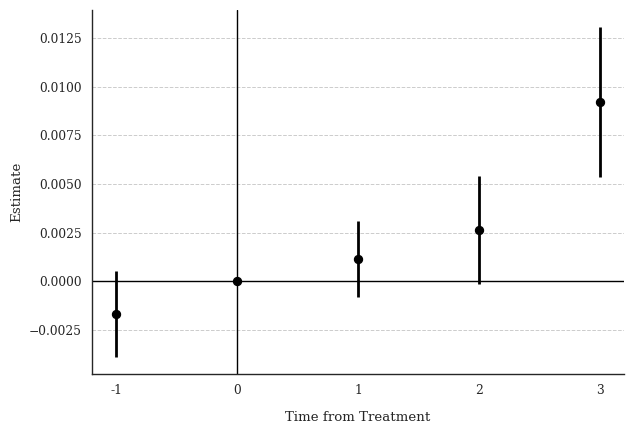

In [79]:
DID(df_rnp)

In [91]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = 0.002704    
se_placebo = 0.000804

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : 3.363
P-value du Placebo : 0.001


### RP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.002704 0.000804  0.001127 0.004280 39544.0     3015.0 39544.0       3015.0
            Effect_2  0.005764 0.001148  0.003515 0.008013 28726.0     2474.0 28726.0       2474.0
            Effect_3  0.009016 0.001581  0.005918 0.012114 18785.0     1873.0 18785.0       1873.0
Average_Total_Effect  0.005338 0.000962  0.003452 0.007224 43897.0     7362.0 43897.0       7362.0
           Placebo_1 -0.001422 0.000964 -0.003310 0.000467 28326.0     2080.0 28326.0       2080.0
Test of joint nullity of the effects: p-value = 0.000000

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


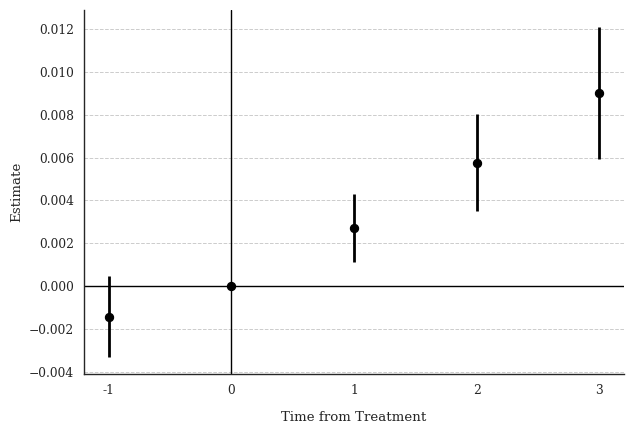

In [75]:
DID(df_rp)

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.008377 0.001418  0.005598  0.011155 12904.0      560.0 12904.0        560.0
            Effect_2  0.017088 0.002271  0.012636  0.021540  9483.0      453.0  9483.0        453.0
            Effect_3  0.014055 0.003216  0.007752  0.020357  6201.0      312.0  6201.0        312.0
Average_Total_Effect  0.012692 0.001807  0.009151  0.016233 13669.0     1325.0 13669.0       1325.0
           Placebo_1 -0.005759 0.001729 -0.009148 -0.002369  9451.0      421.0  9451.0        421.0
Test of joint nullity of the effects: p-value = 0.000000

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


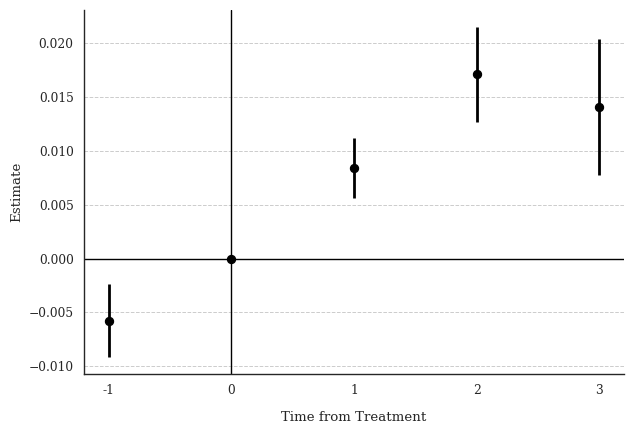

In [76]:
DID(df_ui)

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.020907 0.005036  0.011037  0.030777 2769.0       33.0 2769.0         33.0
            Effect_2  0.032831 0.008506  0.016159  0.049503 2065.0       26.0 2065.0         26.0
            Effect_3  0.007623 0.009942 -0.011862  0.027109 1368.0       17.0 1368.0         17.0
Average_Total_Effect  0.022015 0.005762  0.010722  0.033308 2812.0       76.0 2812.0         76.0
           Placebo_1 -0.020993 0.005690 -0.032146 -0.009840 2064.0       25.0 2064.0         25.0
Test of joint nullity of the effects: p-value = 0.000130

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


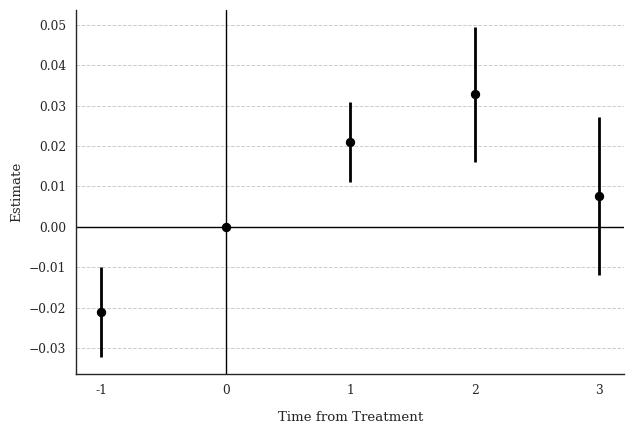

In [77]:
DID(df_ud)